# 비지도학습 AI 모델링

## 비지도학습
: 정답없이 데이터의 패턴과 구조를 학습하는 인공지능 모델링 기법

### 1. 차원축소
고차원 데이터를 더 낮은 차원으로 변환하여 데이터의 중요한 정보를 유지하며 복잡성을 줄이는 기법. 과적합 문제 완화 가능
- 특징 선택 : 데이터에서 중요한 특징만 선택하여 차원 축소
- 특징 추출 : 기존 데이터의 정보를 조합하거나 변환하여 새로운 특징을 생성

### 1) 주성분 분석(PCA) 
고차원 데이터를 저차원으로 변환하여 데이터의 중요한 정보를 유지하며 차원을 축소하는 통계적 기법 

In [1]:
from sklearn.datasets import load_breast_cancer # 사이킷런 라이브러리 dataset에서 load_breast_cancer 가져오기
import pandas as pd
# 데이터로드 
cancer = load_breast_cancer()
# 데이터 프레임으로 변환 (타겟 값 제외)
data = pd.DataFrame(cancer.data, columns = cancer.feature_names)
# 데이터 확인
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [2]:
# 데이터 통계량 확인
data.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


In [12]:
# 1. 데이터 스케일링 
## import 
from sklearn.preprocessing import StandardScaler
## 모델 객체 생성
ss = StandardScaler()
## 데이터 스케일링
scaled_data = ss.fit_transform(data)
## 스케일링된 데이터 프레임 변환
scaled_df = pd.DataFrame(scaled_data, columns = data.columns)
## 데이터 확인
scaled_df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,1.097064,-2.073335,1.269934,0.984375,1.568466,3.283515,2.652874,2.532475,2.217515,2.255747,...,1.886690,-1.359293,2.303601,2.001237,1.307686,2.616665,2.109526,2.296076,2.750622,1.937015
1,1.829821,-0.353632,1.685955,1.908708,-0.826962,-0.487072,-0.023846,0.548144,0.001392,-0.868652,...,1.805927,-0.369203,1.535126,1.890489,-0.375612,-0.430444,-0.146749,1.087084,-0.243890,0.281190
2,1.579888,0.456187,1.566503,1.558884,0.942210,1.052926,1.363478,2.037231,0.939685,-0.398008,...,1.511870,-0.023974,1.347475,1.456285,0.527407,1.082932,0.854974,1.955000,1.152255,0.201391
3,-0.768909,0.253732,-0.592687,-0.764464,3.283553,3.402909,1.915897,1.451707,2.867383,4.910919,...,-0.281464,0.133984,-0.249939,-0.550021,3.394275,3.893397,1.989588,2.175786,6.046041,4.935010
4,1.750297,-1.151816,1.776573,1.826229,0.280372,0.539340,1.371011,1.428493,-0.009560,-0.562450,...,1.298575,-1.466770,1.338539,1.220724,0.220556,-0.313395,0.613179,0.729259,-0.868353,-0.397100


In [13]:
# 2. 주성분 분석 수행
from sklearn.decomposition import PCA
## PCA 객체 생성
pca = PCA(n_components = 10) # 주성분 10개로 생성 
## PCA 적용 
principal_components = pca.fit_transform(scaled_df)
## pca 결과 확인
print(principal_components[:5])

[[ 9.19283683  1.94858307 -1.12316616 -3.6337309   1.19511012  1.41142445
   2.15936987 -0.39840723 -0.15711836 -0.87740188]
 [ 2.3878018  -3.76817174 -0.52929269 -1.11826386 -0.62177498  0.02865635
   0.01335809  0.24098846 -0.71190482  1.10699494]
 [ 5.73389628 -1.0751738  -0.55174759 -0.91208267  0.1770859   0.54145215
  -0.66816648  0.09737374  0.02406564  0.4542754 ]
 [ 7.1229532  10.27558912 -3.23278955 -0.15254703  2.9608784   3.05342182
   1.4299107   1.05956524 -1.40543967 -1.11697527]
 [ 3.93530207 -1.94807157  1.38976673 -2.94063935 -0.5467474  -1.22649464
  -0.93621255  0.63637606 -0.26380546  0.37770447]]


In [21]:
## 설명 분산 비용 확인 
explained_variance_ratio = pca.explained_variance_ratio_
print(explained_variance_ration)

[0.44272026 0.18971182 0.09393163 0.06602135 0.05495768 0.04024522
 0.02250734 0.01588724 0.01389649 0.01168978]


In [24]:
# 3. 시각화
import matplotlib.pyplot as plt
from matplotlib import font_manager
## 한글폰트 
plt.rcParams['font.family'] = 'Malgun Gothic'

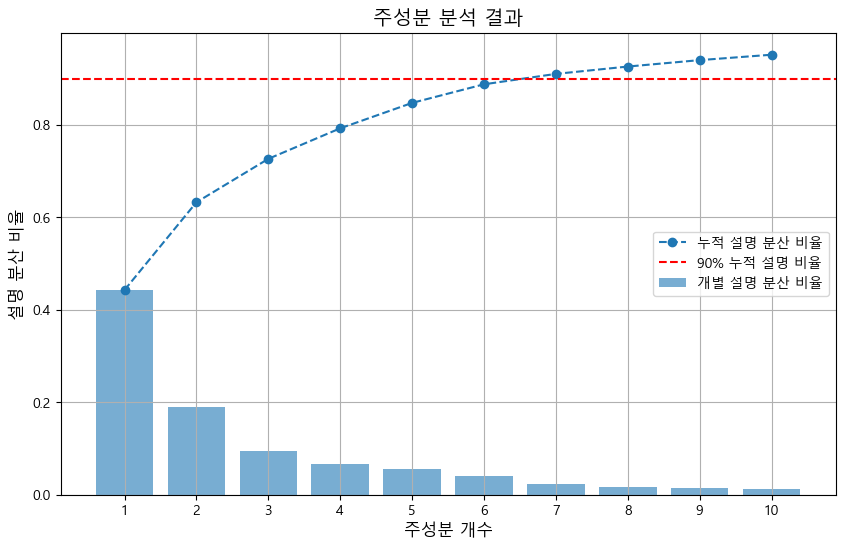

In [26]:
## 그래프 그리기
plt.figure(figsize = (10,6))
plt.plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio.cumsum(), marker = 'o', linestyle = '--', label = '누적 설명 분산 비율')
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha = 0.6, label = '개별 설명 분산 비율')
## 그래프 꾸미기
plt.title('주성분 분석 결과',fontsize = 14)
plt.xlabel('주성분 개수', fontsize = 12)
plt.ylabel('설명 분산 비율', fontsize = 12)
plt.axhline(y = 0.9, color = 'r', linestyle = '--', label = '90% 누적 설명 비율')
plt.xticks(range(1, len(explained_variance_ratio) +1))
plt.legend()
plt.grid()
plt.show()